# Case Study: Bellabeat Data Analysis 

**Author: Nikodem Kijas** 

**Tool Used: Pandas, Matplotlib, Seaborn**

# 1. Ask
Bellabeat is company

## 2. Prepare


### 2.1. Importing packages


In [271]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 2.2. Importing csv's

In [272]:
dailyActivity_df = pd.read_csv('./csv/dailyActivity_merged.csv')
sleep_df = pd.read_csv('./csv/minuteSleep_merged.csv')
intensity_df = pd.read_csv('./csv/hourlyintensities_merged.csv')
weight_df = pd.read_csv("./csv/weightLogInfo_merged.csv")
minuteMets = pd.read_csv("./csv/minuteMETsNarrow_merged.csv")

### 2.3. Cleaning & Transforming Data

In [273]:
dailyActivity_df.drop_duplicates(inplace=True)  
dailyActivity_df["ActivityDate"] = pd.to_datetime(dailyActivity_df["ActivityDate"], format="%m/%d/%Y")

sleep_df.drop_duplicates(inplace=True)
sleep_df["data"] = pd.to_datetime(sleep_df["date"])
sleep_df["ActivityDate"] = sleep_df["data"].dt.normalize()

intensity_df["ActivityHour"] = pd.to_datetime(intensity_df["ActivityHour"], format="%m/%d/%Y %I:%M:%S %p")
intensity_df["Date"] = intensity_df["ActivityHour"].dt.normalize()

minuteMets["METs"] = minuteMets["METs"] / 10.0

### 2.4. Feature Engineering

In [274]:
dailyActivity_df["DayOfWeek"] = dailyActivity_df["ActivityDate"].dt.day_name()
dailyActivity_df["TotalWearMinutes"] = dailyActivity_df["FairlyActiveMinutes"] + dailyActivity_df["VeryActiveMinutes"] + dailyActivity_df["LightlyActiveMinutes"] + dailyActivity_df["SedentaryMinutes"]
dailyActivity_df["WearsAllDay"] = dailyActivity_df["TotalWearMinutes"] >= 24*60*0.9
dailyActivity_df["MadeEightThousendSteps"] = dailyActivity_df["TotalSteps"] > 8000

real_sleep = sleep_df[sleep_df["value"] == 1]
sleep_summary = real_sleep.groupby(["Id", "ActivityDate"])["value"].sum().reset_index()
sleep_summary.rename(columns={"value": "SleepMinutes"}, inplace=True)

time_in_bed = sleep_df.groupby(["Id", "ActivityDate"])["value"].count().reset_index()

sleep_summary = sleep_summary.merge(time_in_bed, on=["Id", "ActivityDate"], how="left")
sleep_summary.rename(columns={"value": "TimeInBedMinutes"}, inplace=True)   

sleep_summary["AwakeInBedMinutes"] = sleep_summary["TimeInBedMinutes"] - sleep_summary["SleepMinutes"]
sleep_summary["SleepOver8"] = sleep_summary["SleepMinutes"] > 8 * 60



minuteMets["Intensity"] = pd.cut(minuteMets["METs"], bins=[1.5, 3.0, 6.0, 20], labels=["lightly active", "fairly active", "very active"])

intensity_df["Hour"] = intensity_df["ActivityHour"].dt.hour


### 2.5. Filtering & Grouping

In [275]:
filteredDailyActivity_df = dailyActivity_df[(dailyActivity_df["TotalSteps"] > 0) & (dailyActivity_df["SedentaryMinutes"] < 24*60)]
steps = filteredDailyActivity_df.groupby("MadeEightThousendSteps")["TotalSteps"].count()
wearsAllDay = dailyActivity_df.groupby("WearsAllDay")["WearsAllDay"].count()
steps_by_day = filteredDailyActivity_df.groupby("DayOfWeek")["TotalSteps"].mean().reset_index()
MeanWearTime = filteredDailyActivity_df["TotalWearMinutes"].mean()

hour_intensity = intensity_df.groupby("Hour")["AverageIntensity"].mean().reset_index()

intensity = minuteMets["Intensity"].value_counts().reset_index()

sleepTime = sleep_summary.groupby("SleepOver8")["SleepOver8"].count()
meanTimeInBedAwake = sleep_summary["AwakeInBedMinutes"].mean()


# 3. Analyze & Share




### 3.1. Do users actually wear the device all day?

Mean time of wearing band during the day is 19 hours 24 minutes


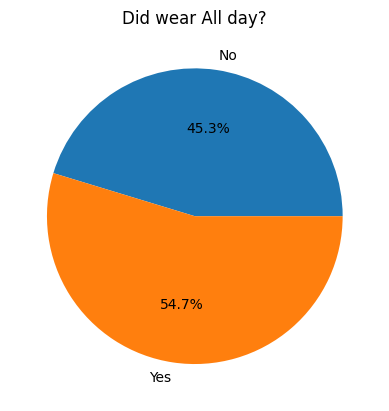

In [276]:
print(f"Mean time of wearing band during the day is {MeanWearTime/60:.0f} hours {MeanWearTime%60:.0f} minutes")

plt.pie(
    wearsAllDay,
    labels = ["No", "Yes"],
    autopct='%1.1f%%',
)
plt.title("Did wear All day?")
plt.show()

#### 

#### The chart above shows that almost half of the users (45.3%) do not wear the band all day. In addition, the average wear time is 19 hours and 24 minutes. 
#### This drop of engagement might be caused by poor batery life or physical discomfort. 

#### Bellabeat should investigate hardware improvements focusing on battery longevity and strap comfort. 



#### 3.2. When do our users moves? 

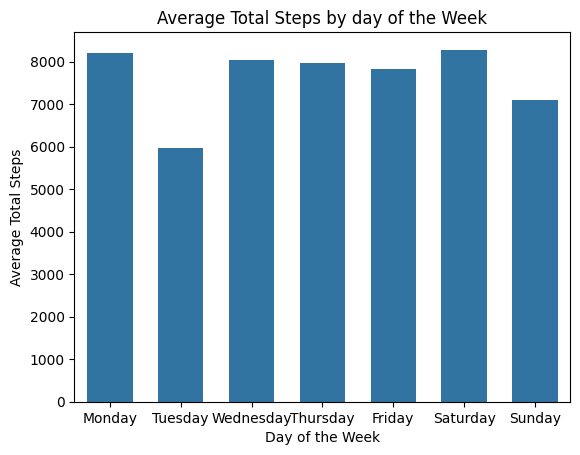

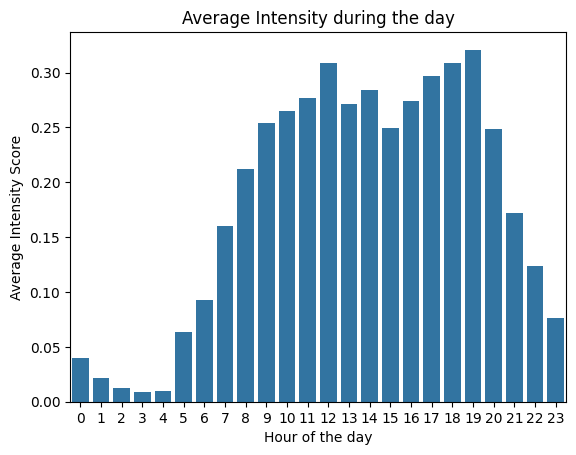

In [277]:
sns.barplot(filteredDailyActivity_df,
            x="DayOfWeek", 
            y="TotalSteps", 
            order=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"],
            errorbar=None, 
            gap=0.2)
plt.title("Average Total Steps by day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Average Total Steps")
plt.show()

sns.barplot(hour_intensity, x="Hour", y="AverageIntensity")
plt.title("Average Intensity during the day")
plt.xlabel("Hour of the day")
plt.ylabel("Average Intensity Score")
plt.show()


#### We can notice visible drop in activity on Tuesdays and Sundays.
#### During the day there are two peaks in activity, the first one starts at 12:00, larger one occurs around around 19

#### Bellabeat could send a notification around 12:00 to remind users to stand up and move around. 
#### Another notification should be scheduled just before evening peek to motivate users to hit the gym or do another workout. 
#### On Tuesday and Sunday the app should push notification to motivate users to went for a walk

### 3.3. Are users recovering properly?

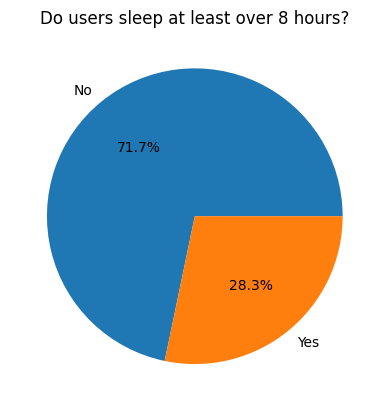

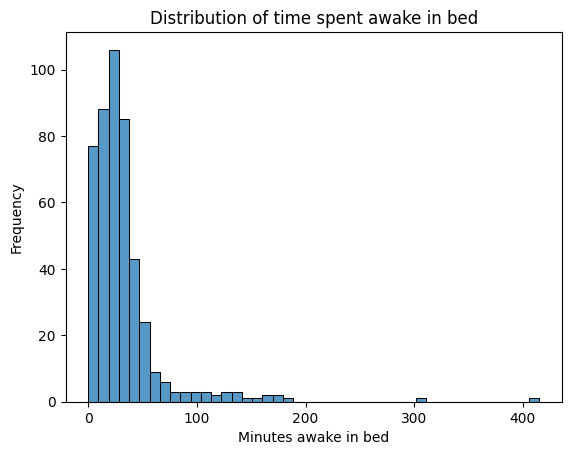

Mean time of staying awake in bed is 32 minutes


In [278]:
plt.pie(sleepTime,
        labels=["No", "Yes"],
        autopct='%1.1f%%'
        )
plt.title("Do users sleep at least over 8 hours?")
plt.show()


sns.histplot(sleep_summary["AwakeInBedMinutes"])
plt.xlabel("Minutes awake in bed")
plt.ylabel("Frequency")
plt.title("Distribution of time spent awake in bed")
plt.show()

print(f"Mean time of staying awake in bed is {meanTimeInBedAwake:.0f} minutes")

#### 71% of the recorded nights show that users fail to get recommended 8 hours of sleep.
#### Users spend an average 32 minutes awake, but as we can see from histogram, a part of users struggle with much bigger problems.

#### To improve users sleep quality, the app should feature educational section about healthy habbits that promotes better rest. 
#### In addition we might consider adding feature where user sets their desired bed time, the app help user to wind down before the bed time. 
#### Bellabear could introduce smart alarm. The tracker would detect exact moment the user fall asleep and set the alarm to wake them up after 8 hours of sleep.

### 3.4. Why steps aren't everything?

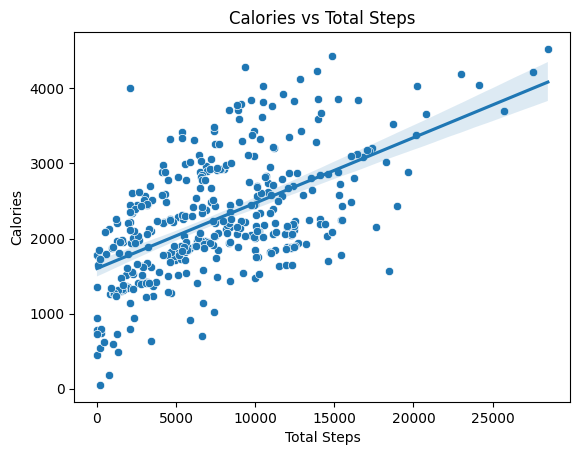

In [279]:
sns.scatterplot(filteredDailyActivity_df, x="TotalSteps" , y="Calories")
plt.title("Calories vs Total Steps")
sns.regplot(filteredDailyActivity_df, x="TotalSteps", y="Calories", scatter = False)
plt.xlabel("Total Steps")
plt.show()

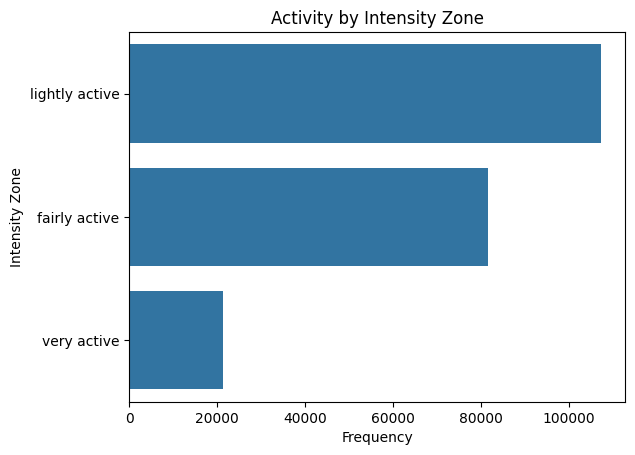

In [280]:
sns.barplot(intensity,
             x="count",
             y="Intensity")
plt.title("Activity by Intensity Zone")
plt.xlabel("Frequency")
plt.ylabel("Intensity Zone")
plt.show()

# 4. Act
